<a href="https://colab.research.google.com/github/kmeng01/rome/blob/main/notebooks/causal_trace.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" align="left"/></a>&nbsp;or in a local notebook.

## 前置作業

In [ ]:
%%bash
!(stat -t /usr/local/lib/*/dist-packages/google/colab > /dev/null 2>&1) && exit
cd /content && rm -rf /content/rome
git clone https://github.com/kmeng01/rome rome > install.log 2>&1
pip install -r /content/rome/scripts/colab_reqs/rome.txt >> install.log 2>&1
pip install --upgrade google-cloud-storage >> install.log 2>&1

In [ ]:
IS_COLAB = False
try:
    import google.colab, torch, os

    IS_COLAB = True
    os.chdir("/content/rome")
    if not torch.cuda.is_available():
        raise Exception("Change runtime type to include a GPU.")
except ModuleNotFoundError as _:
    pass

In [ ]:
!wget -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
import matplotlib.font_manager as fm; fm.fontManager.addfont("/content/TimesNewRoman.ttf")

--2025-12-25 16:55:24--  https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf [following]
--2025-12-25 16:55:24--  https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 834452 (815K) [application/octet-stream]
Saving to: ‘/content/TimesNewRoman.ttf’

/content/TimesNewRo 100%[===================>] 814.89K  --.-KB/s    in 0.03s   

2025-12-25 16:55:24 (26.8 MB/s) - ‘/content/TimesNewRoman.ttf’ saved [834452/

## Causal Tracing

A demonstration of the double-intervention causal tracing method.

The strategy used by causal tracing is to understand important
states within a transfomer by doing two interventions simultaneously:

1. Corrupt a subset of the input.  In our paper, we corrupt the subject tokens
   to frustrate the ability of the transformer to accurately complete factual
   prompts about the subject.
2. Restore a subset of the internal hidden states.  In our paper, we scan
   hidden states at all layers and all tokens, searching for individual states
   that carry the necessary information for the transformer to recover its
   capability to complete the factual prompt.

The traces of decisive states can be shown on a heatmap.  This notebook
demonstrates the code for conducting causal traces and creating these heatmaps.

The `experiments.causal_trace` module contains a set of functions for running causal traces.

In this notebook, we reproduce, demonstrate and discuss the interesting functions.

We begin by importing several utility functions that deal with tokens and transformer models.

In [ ]:
import os, re, json
import torch, numpy
from collections import defaultdict
from util import nethook
from util.globals import DATA_DIR
from experiments.causal_trace import (
    ModelAndTokenizer,
    layername,
    guess_subject,
    plot_trace_heatmap,
    trace_important_window
)
from experiments.causal_trace import (
    make_inputs,
    decode_tokens,
    find_token_range,
    predict_token,
    predict_from_input,
    collect_embedding_std,
)
from dsets import KnownsDataset

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

Now we load a model and tokenizer, and show that it can complete a couple factual statements correctly.

In [ ]:
model_name = "gpt2-xl"  # or "EleutherAI/gpt-j-6B" or "EleutherAI/gpt-neox-20b"
mt = ModelAndTokenizer(
    model_name,
    low_cpu_mem_usage=IS_COLAB,
    torch_dtype=(torch.float16 if "20b" in model_name else None),
)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
help(ModelAndTokenizer)

Help on class ModelAndTokenizer in module experiments.causal_trace:

class ModelAndTokenizer(builtins.object)
 |  ModelAndTokenizer(model_name=None, model=None, tokenizer=None, low_cpu_mem_usage=False, torch_dtype=None)
 |
 |  An object to hold on to (or automatically download and hold)
 |  a GPT-style language model and tokenizer.  Counts the number
 |  of layers.
 |
 |  Methods defined here:
 |
 |  __init__(self, model_name=None, model=None, tokenizer=None, low_cpu_mem_usage=False, torch_dtype=None)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __repr__(self)
 |      Return repr(self).
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



In [ ]:
help(predict_token)

Help on function predict_token in module experiments.causal_trace:

predict_token(mt, prompts, return_p=False)



要預測的句子

In [ ]:
predict_token(
    mt,
    ["New Taipei City is the most populous city in"],
    return_p=True,
)

([' Taiwan'], tensor([0.8599], device='cuda:0'))

To obfuscate the subject during Causal Tracing, we use noise sampled from a zero-centered spherical Gaussian, whose stddev is 3 times the $\sigma$ stddev the model's embeddings. Let's compute that value.

In [ ]:
knowns = KnownsDataset(DATA_DIR)  # Dataset of known facts
noise_level = 3 * collect_embedding_std(mt, [k["subject"] for k in knowns])
print(f"Using noise level {noise_level}")

data/known_1000.json does not exist. Downloading from https://rome.baulab.info/data/dsets/known_1000.json


100%|██████████| 335k/335k [00:00<00:00, 2.11MB/s]


Loaded dataset with 1209 elements
Using noise level 0.13462981581687927


## Tracing a single location

The core intervention in causal tracing is captured in this function:

`trace_with_patch` a single causal trace.

It enables running a batch of inferences with two interventions.

  1. Random noise can be added to corrupt the inputs of some of the batch.
  2. At any point, clean non-noised state can be copied over from an
     uncorrupted batch member to other batch members.
  
The convention used by this function is that the zeroth element of the
batch is the uncorrupted run, and the subsequent elements of the batch
are the corrupted runs.  The argument tokens_to_mix specifies an
be corrupted by adding Gaussian noise to the embedding for the batch
inputs other than the first element in the batch.  Alternately,
subsequent runs could be corrupted by simply providing different
input tokens via the passed input batch.

To ensure that corrupted behavior is representative, in practice, we
will actually run several (ten) corrupted runs in the same batch,
each with its own sample of noise.

Then when running, a specified set of hidden states will be uncorrupted
by restoring their values to the same vector that they had in the
zeroth uncorrupted run.  This set of hidden states is listed in
states_to_patch, by listing [(token_index, layername), ...] pairs.
To trace the effect of just a single state, this can be just a single
token/layer pair.  To trace the effect of restoring a set of states,
any number of token indices and layers can be listed.

Note that this function is also in experiments.causal_trace; the code
is shown here to show the logic.

In [ ]:
def trace_with_patch(
    model,
    inp,
    states_to_patch,
    answers_t,
    tokens_to_mix,
    noise=0.1,
    trace_layers=None,
):
    prng = numpy.random.RandomState(1)

    patch_spec = defaultdict(list)
    for t, l in states_to_patch:
        patch_spec[l].append(t)

    embed_layername = layername(model, 0, "embed")

    def untuple(x):
        return x[0] if isinstance(x, tuple) else x

    def patch_rep(x, layer):
        if layer == embed_layername:
            if tokens_to_mix is not None:
                b, e = tokens_to_mix
                x[1:, b:e] += noise * torch.from_numpy(
                    prng.randn(x.shape[0] - 1, e - b, x.shape[2])
                ).to(x.device)
            return x

        if layer not in patch_spec:
            return x

        h = untuple(x)
        for t in patch_spec[layer]:
            h[1:, t] = h[0, t]
        return x

    additional_layers = [] if trace_layers is None else trace_layers
    with torch.no_grad(), nethook.TraceDict(
        model,
        [embed_layername] + list(patch_spec.keys()) + additional_layers,
        edit_output=patch_rep,
    ) as td:
        outputs_exp = model(**inp)

    probs = torch.softmax(outputs_exp.logits[1:, -1, :], dim=1).mean(dim=0)[answers_t]

    if trace_layers is not None:
        all_traced = torch.stack(
            [untuple(td[layer].output).detach().cpu() for layer in trace_layers], dim=2
        )
        return probs, all_traced

    return probs

## Scanning all locations

A causal flow heatmap is created by repeating `trace_with_patch` at every individual hidden state, and measuring the impact of restoring state at each location.

The `calculate_hidden_flow` function does this loop.  It handles both the case of restoring a single hidden state, and also restoring MLP or attention states.  Because MLP and attention make small residual contributions, to observe a causal effect in those cases, we need to restore several layers of contributions at once, which is done by `trace_important_window`.

In [ ]:
def calculate_hidden_flow(
    mt,
    prompt,
    subject,
    samples=10,
    noise=0.1,
    window=10,
    kind=None
):
    """
    對網路中的每一個 Token 和 Layer 組合執行因果追蹤 (Causal Tracing)，
    並返回一個字典，數值化地總結結果。
    """
    inp = make_inputs(mt.tokenizer, [prompt] * (samples + 1))

    with torch.no_grad():
        answer_t, base_score = [d[0] for d in predict_from_input(mt.model, inp)]

    [answer] = decode_tokens(mt.tokenizer, [answer_t])
    e_range = find_token_range(mt.tokenizer, inp["input_ids"][0], subject)

    low_score = trace_with_patch(
        mt.model, inp, [], answer_t, e_range, noise=noise
    ).item()


    if not kind:
        differences = trace_important_states(
            mt.model, mt.num_layers, inp, e_range, answer_t, noise=noise
        )
    else:
        differences = trace_important_window(
            mt.model,
            mt.num_layers,
            inp,
            e_range,
            answer_t,
            noise=noise,
            window=window,
            kind=kind,
        )
    differences = differences.detach().cpu()

    return dict(
        scores=differences,
        low_score=low_score,
        high_score=base_score,
        input_ids=inp["input_ids"][0],
        input_tokens=decode_tokens(mt.tokenizer, inp["input_ids"][0]),
        subject_range=e_range,
        answer=answer,
        window=window,
        kind=kind or "",
    )


def trace_important_states(model, num_layers, inp, e_range, answer_t, noise=0.1):
    """
    針對矩陣中的每一個 (Token, Layer) 進行單點修復測試。
    """
    ntoks = inp["input_ids"].shape[1]
    table = []

    for tnum in range(ntoks):
        row = []
        for layer in range(0, num_layers):
            r = trace_with_patch(
                model,
                inp,
                [(tnum, layername(model, layer))],
                answer_t,
                tokens_to_mix=e_range,
                noise=noise,
            )
            row.append(r)
        table.append(torch.stack(row))
    return torch.stack(table)

# Heat map

正在執行 Causal Tracing...

### To do 2: 機率與 TE/IE 統計表
| 句子事實   |   Clean Run P |   Corrupted Run P |   Total Effect (TE) |   Max IE |   關鍵層 (Max IE Layer) |
|:-----------|--------------:|------------------:|--------------------:|---------:|------------------------:|
| Taiwan     |        0.8599 |            0.1762 |              0.6837 |   0.8961 |                       9 |
| Elon Musk  |        0.2755 |            0.1744 |              0.1011 |   0.3013 |                       6 |
| Paris      |        0.8232 |            0.0149 |              0.8083 |   0.8232 |                       8 |


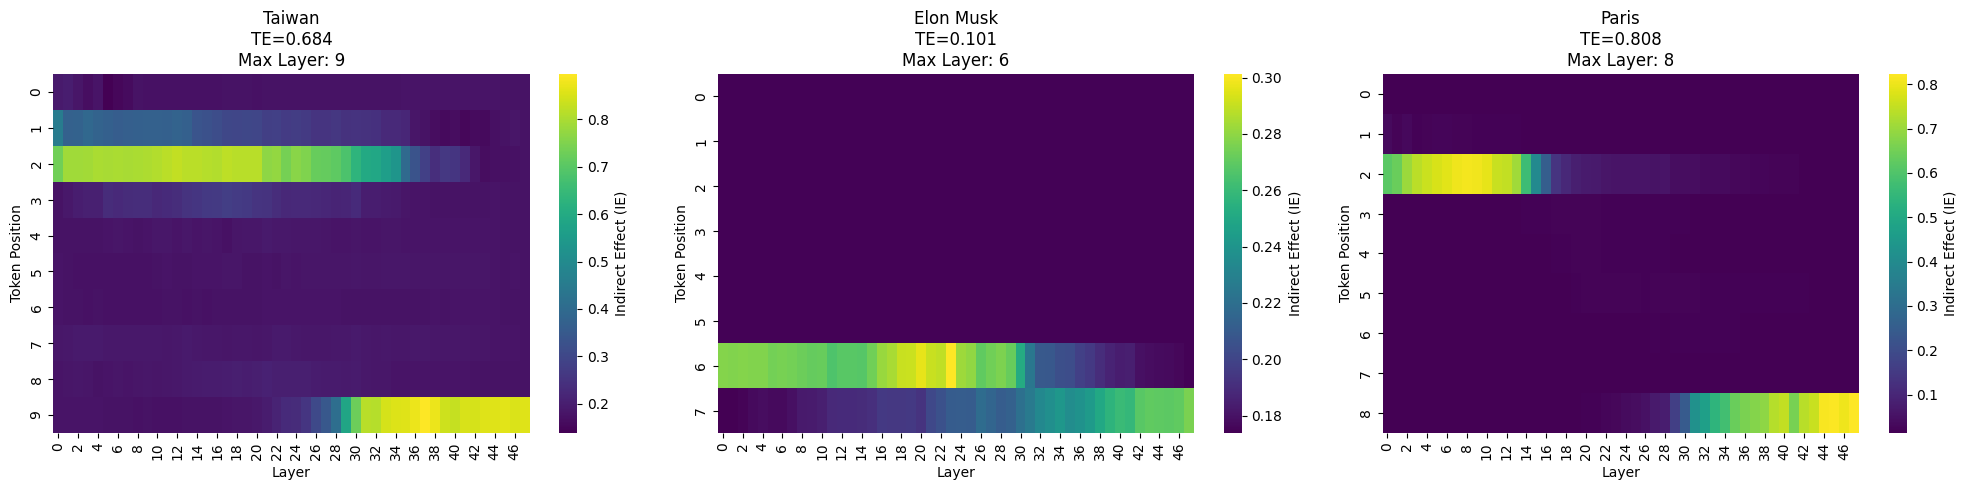



- **Taiwan**: TE 為 0.6837，顯示因果效應顯著。最大 IE 出現在第 **9** 層，證實該層 MLP 儲存了關鍵事實知識。
- **Elon Musk**: TE 為 0.1011，顯示因果效應顯著。最大 IE 出現在第 **6** 層，證實該層 MLP 儲存了關鍵事實知識。
- **Paris**: TE 為 0.8083，顯示因果效應顯著。最大 IE 出現在第 **8** 層，證實該層 MLP 儲存了關鍵事實知識。


In [ ]:
# To do 2: Causal Tracing
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

# 1. 定義三句測試句子
test_cases = [
    {
        "prompt": "New Taipei City is the most populous city in",
        "subject": "New Taipei City",
        "fact": "Taiwan"
    },
    {
        "prompt": "The current richest person in the world is",
        "subject": "world",
        "fact": "Elon Musk"
    },
    {
        "prompt": "The Louvre is located in the city of",
        "subject": "Louvre",
        "fact": "Paris"
    }
]

# 2. 執行 Causal Tracing 並計算指標
results = {}
table_data = []

print("正在執行 Causal Tracing...")
for i, case in enumerate(test_cases):

    flow = calculate_hidden_flow(
        mt, case['prompt'], case['subject'],
        samples=10, noise=noise_level
    )

    high = float(flow['high_score'])
    low = float(flow['low_score'])
    te = high - low
    scores = flow['scores']  # Tensor

    max_ie_idx = torch.argmax(scores)
    max_layer = max_ie_idx.item() // scores.shape[1]
    max_ie_val = scores.max().item()

    # 存儲結果
    results[case['fact']] = {
        'te': te,
        'scores': scores,
        'max_layer': max_layer
    }

    # 表格數據
    table_data.append({
        "句子事實": case['fact'],
        "Clean Run P": f"{high:.4f}",
        "Corrupted Run P": f"{low:.4f}",
        "Total Effect (TE)": f"{te:.4f}",
        "Max IE": f"{max_ie_val:.4f}",
        "關鍵層 (Max IE Layer)": max_layer
    })

# 3. 輸出統計表格
print("\n### To do 2: 機率與 TE/IE 統計表")
df = pd.DataFrame(table_data)
print(df.to_markdown(index=False))

# 4. 繪製三張熱圖
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, fact in enumerate(["Taiwan", "Elon Musk", "Paris"]):
    scores = results[fact]['scores'].detach().cpu().numpy()
    sns.heatmap(scores, ax=axes[i], cmap='viridis',
                cbar_kws={'label': 'Indirect Effect (IE)'})

    # 標示最大 IE 點
    max_layer = results[fact]['max_layer']
    axes[i].set_title(f'{fact}\nTE={results[fact]["te"]:.3f}\nMax Layer: {max_layer}')
    axes[i].set_xlabel('Layer')
    axes[i].set_ylabel('Token Position')

plt.tight_layout()
plt.savefig('todo2_results.png', dpi=300)
plt.show()

# 5. 自動輸出結果說明模板
print("\n")
for data in table_data:
    fact = data['句子事實']
    layer = data['關鍵層 (Max IE Layer)']
    te = data['Total Effect (TE)']
    print(f"- **{fact}**: TE 為 {te}，顯示因果效應顯著。最大 IE 出現在第 **{layer}** 層，證實該層 MLP 儲存了關鍵事實知識。")


## Plotting the results

The `plot_trace_heatmap` function draws the data on a heatmap.  That function is not shown here; it is in `experiments.causal_trace`.


In [ ]:
def plot_hidden_flow(
    mt,
    prompt,
    subject=None,
    samples=10,
    noise=0.1,
    window=10,
    kind=None,
    modelname=None,
    savepdf=None,
):
    if subject is None:
        subject = guess_subject(prompt)
    result = calculate_hidden_flow(
        mt, prompt, subject, samples=samples, noise=noise, window=window, kind=kind
    )
    plot_trace_heatmap(result, savepdf, modelname=modelname)


def plot_all_flow(mt, prompt, subject=None, noise=0.1, modelname=None):
    for kind in [None, "mlp", "attn"]:
        plot_hidden_flow(
            mt, prompt, subject, modelname=modelname, noise=noise, kind=kind
        )

The following prompt can be changed to any factual statement to trace.

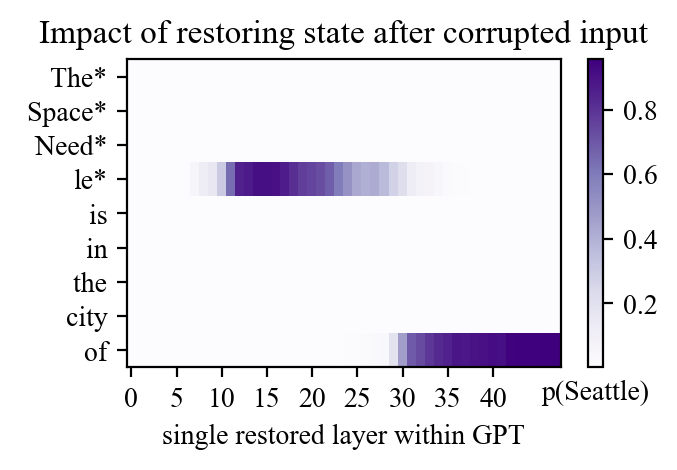

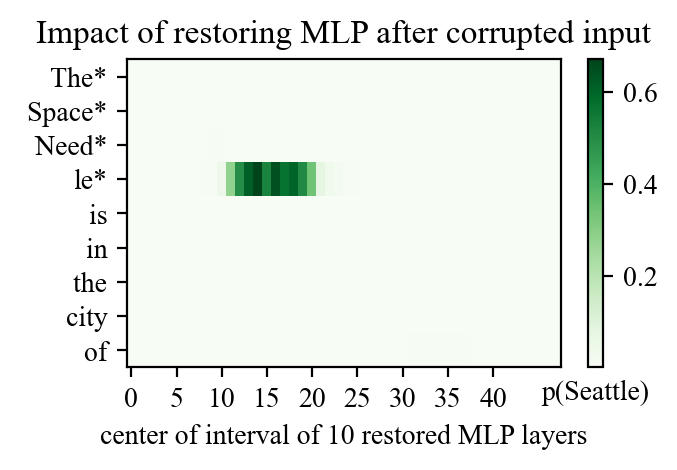

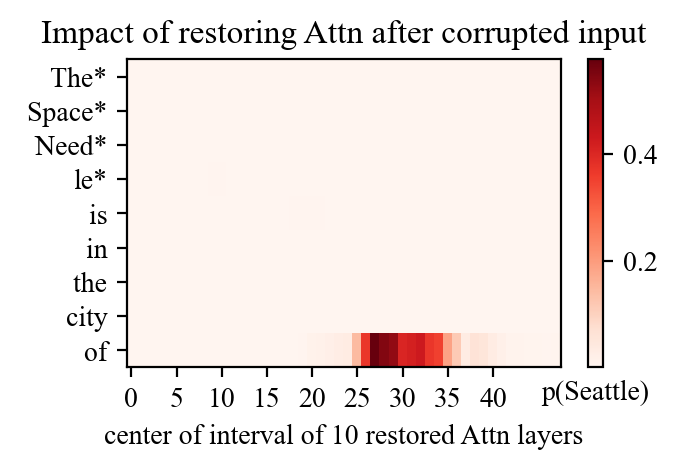

In [ ]:
plot_all_flow(mt, "The Space Needle is in the city of", noise=noise_level)

Here we trace a few more factual statements from a file of test cases.

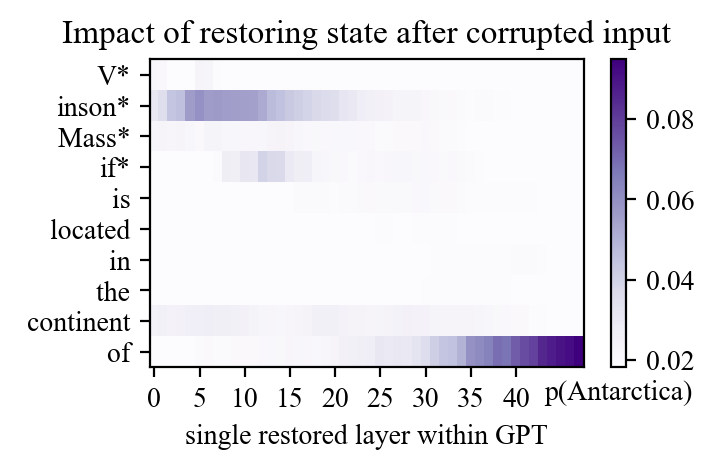

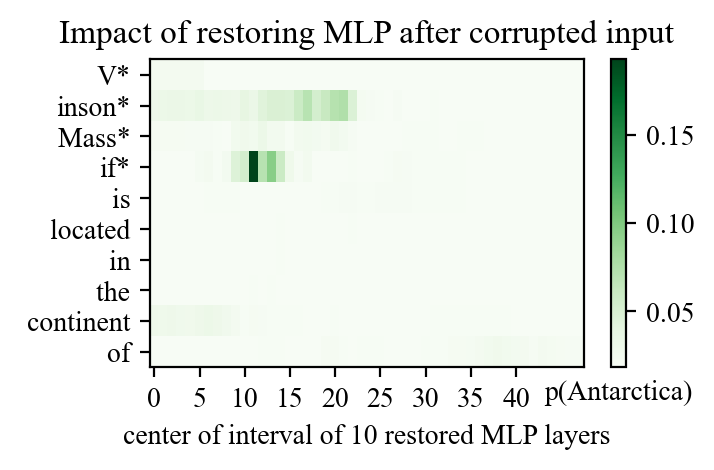

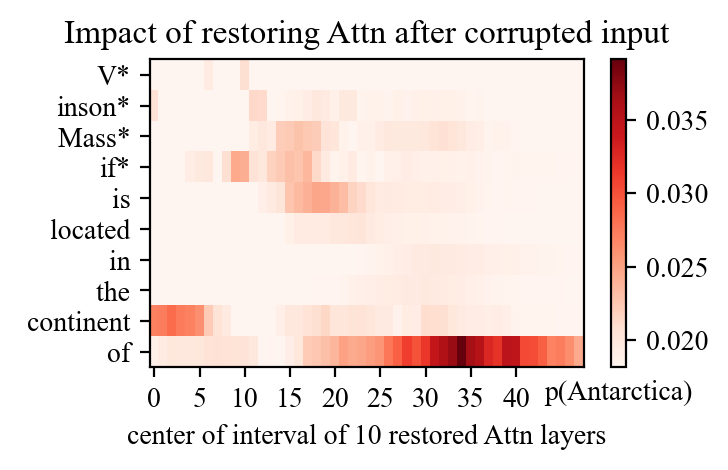

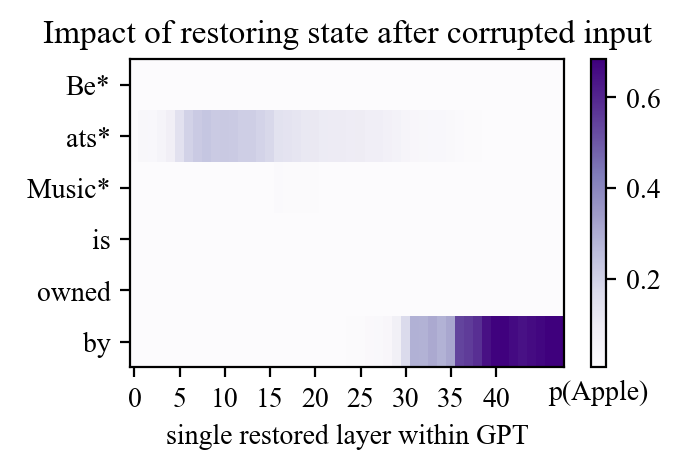

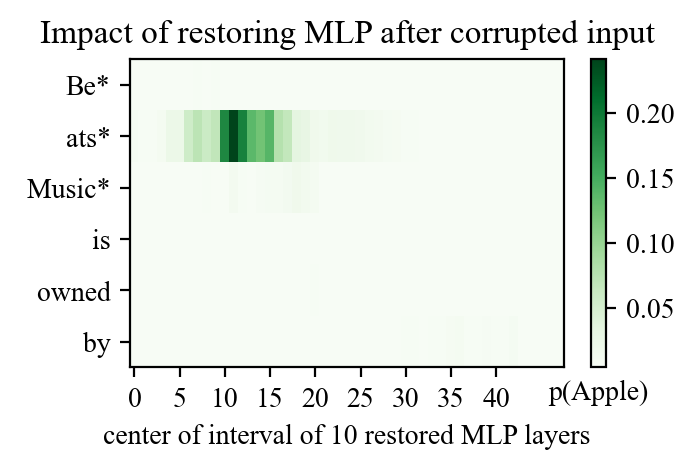

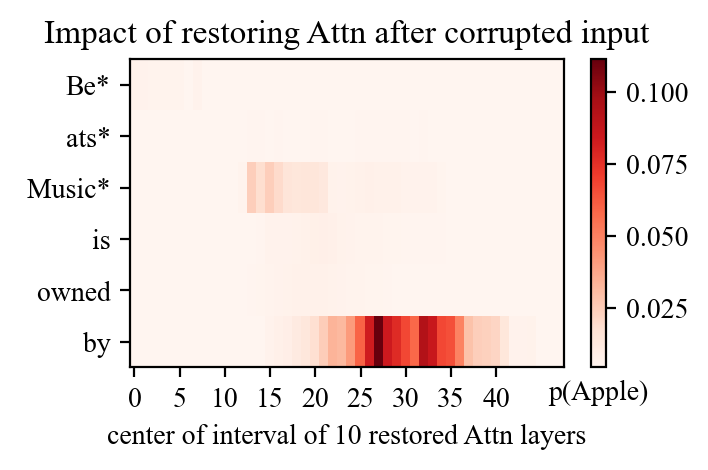

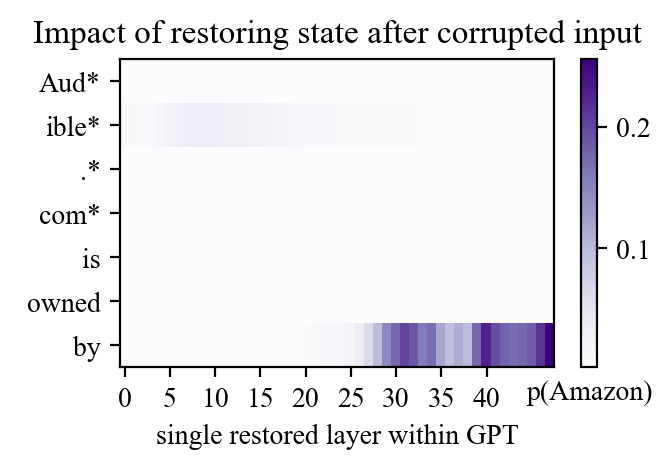

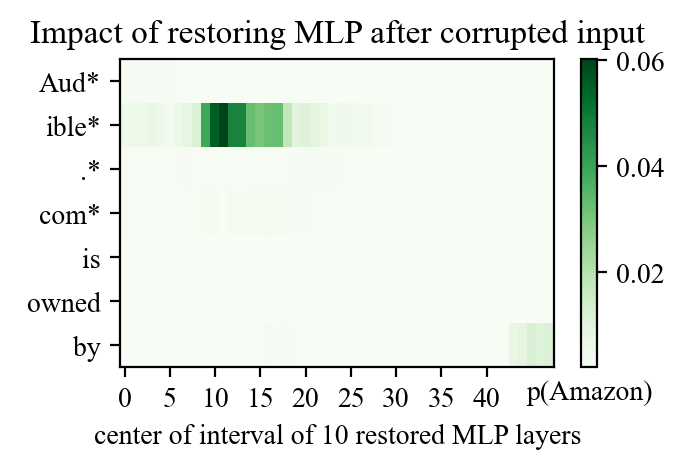

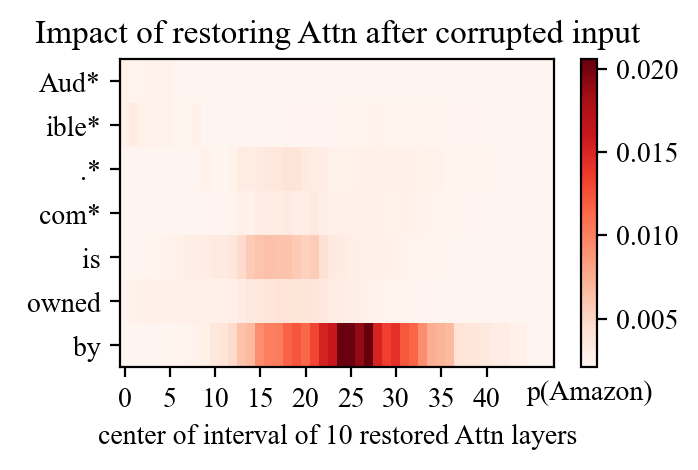

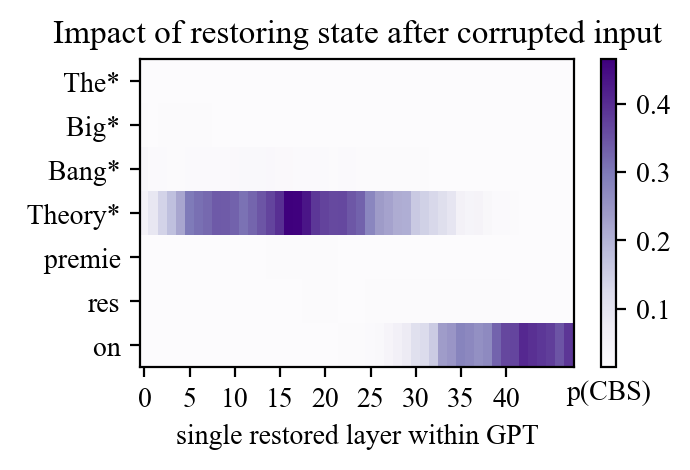

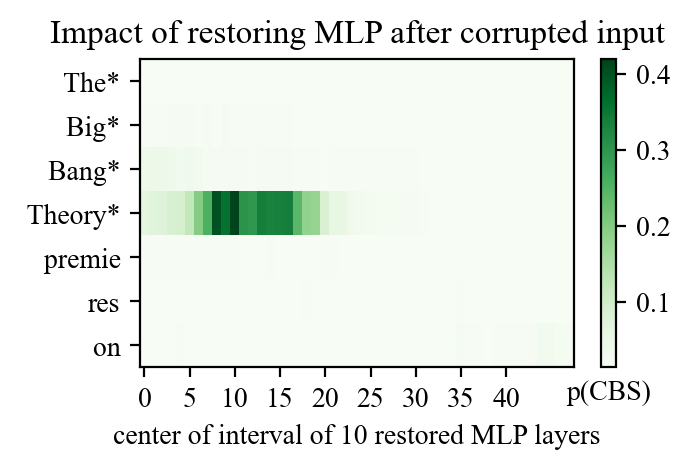

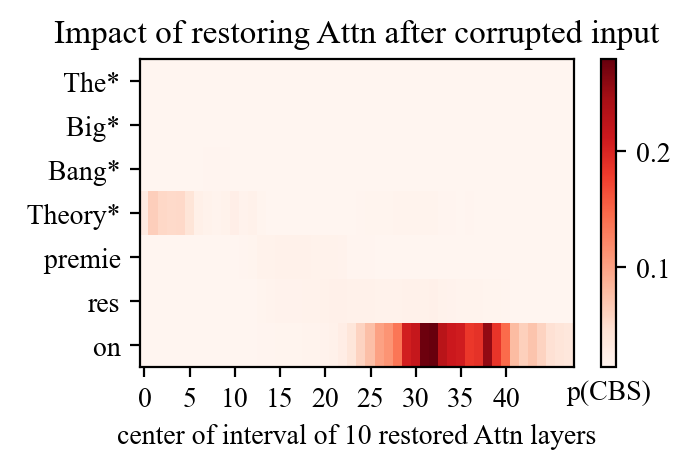

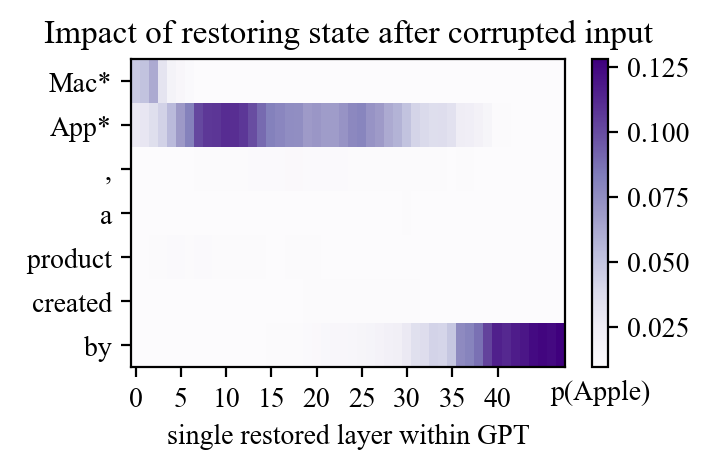

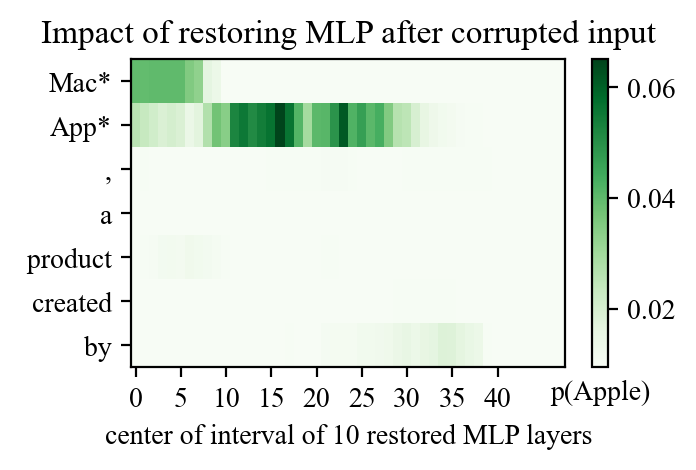

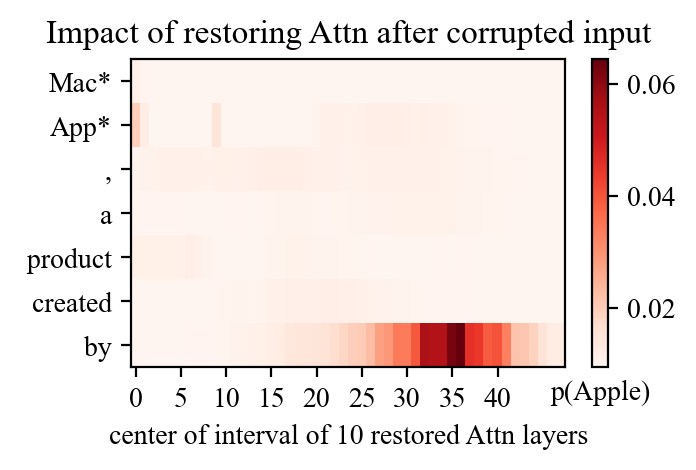

In [ ]:
for knowledge in knowns[:5]:
    plot_all_flow(mt, knowledge["prompt"], knowledge["subject"], noise=noise_level)